# **Evaluation Pretrained Models Notebook**

### **Wikiart Project**

**Group 22:**\
**Afonso Hermenegildo** - 20221958 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951 | **André Nicolau** - 20221918 | **André Ferreira** - 20250398

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

0. *Imports*
1. *Load datasets and model*
2. *Make predictions*
3. *Classification report*
4. *Confusion matrix*
5. *Grad-CAM*
6. *Misclassified samples*


---

# 0. Imports

In [1]:
import sys
sys.path.append('..')
sys.path.append('../scripts')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # hide tensorflow errors

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

gpus = tf.config.list_physical_devices('GPU')
print(gpus)

for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(3.8*1024))]
    )

import keras
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory

E0000 00:00:1777043405.795004   44321 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777043405.802777   44321 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777043405.823391   44321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777043405.823446   44321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777043405.823448   44321 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777043405.823450   44321 computation_placer.cc:177] computation placer already registered. Please check linka

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 1. Load datasets and model

In [2]:
OUTPUTS_DIR = "../outputs"
FIGURES_DIR = OUTPUTS_DIR + "/figures"

TEST_PATH = "../clean_split_data/Test"

MODEL_PATH = OUTPUTS_DIR + "/models/convnext_large_finetuned.keras"

IMAGE_SIZE = (512, 512)
INPUT_SHAPE = IMAGE_SIZE + (3,)
BATCH_SIZE = 2

In [3]:
test_ds = image_dataset_from_directory(
    TEST_PATH,
    label_mode="categorical",
    interpolation="bilinear",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=False
)

class_names = test_ds.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 2000 files belonging to 23 classes.
Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


I0000 00:00:1777043415.747805   44321 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [4]:
model = keras.saving.load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

Model loaded from: ../outputs/models/convnext_large_finetuned.keras


In [5]:
model.summary()

Model: "convnext_large_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 16, 16, 1536)   │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        35,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,265,689 (748.69 MB)

 Trainable params: 18,998,807 (72.47 MB)

 Non-trainable params: 177,266,880 (676.22 MB)

 Optimizer params: 2 (12.00 B)

# 2. Make predictions

In [6]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

I0000 00:00:1777042750.276777   33826 service.cc:152] XLA service 0x7701bc003560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777042750.276859   33826 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1777042750.866431   33826 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777042777.741898   33826 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Getting a score on the test set

In [7]:
model.evaluate(test_ds)

125/125 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - categorical_accuracy: 0.8450 - f1_score: 0.8370 - loss: 0.5006


[0.5005671977996826, 0.8450000286102295, 0.8369684815406799]

## 3. Classification report

Primary metric for this project is **macro-F1** because classes may be imbalanced. <br>
Macro-F1 gives equal weight to all classes regardless of size. <br>
If macro-F1 is much lower than accuracy, the model is biased toward majority classes. <br>

In [8]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR + '/classification_report_pretrained.txt', 'w') as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.94      0.87      0.90        87
      Boris_Kustodiev       0.84      0.79      0.82        67
     Camille_Pissarro       0.89      0.69      0.78        93
        Childe_Hassam       0.87      0.70      0.78        57
         Claude_Monet       0.76      0.89      0.82       140
          Edgar_Degas       0.63      0.88      0.73        64
        Eugene_Boudin       1.00      0.88      0.94        58
         Gustave_Dore       0.95      0.97      0.96        80
           Ilya_Repin       0.84      0.68      0.75        56
      Ivan_Aivazovsky       0.90      0.93      0.92        60
        Ivan_Shishkin       0.78      0.91      0.84        54
  John_Singer_Sargent       0.78      0.83      0.81        83
         Marc_Chagall       0.93      0.85      0.89        81
      Martiros_Saryan       0.91      0.69      0.79        61
     Nicholas_Roerich       0.92      0.92      0.92  

## 4. Confusion matrix

The diagonal = correct predictions. Off-diagonal = errors. <br>
Look for clusters of errors between visually similar classes.

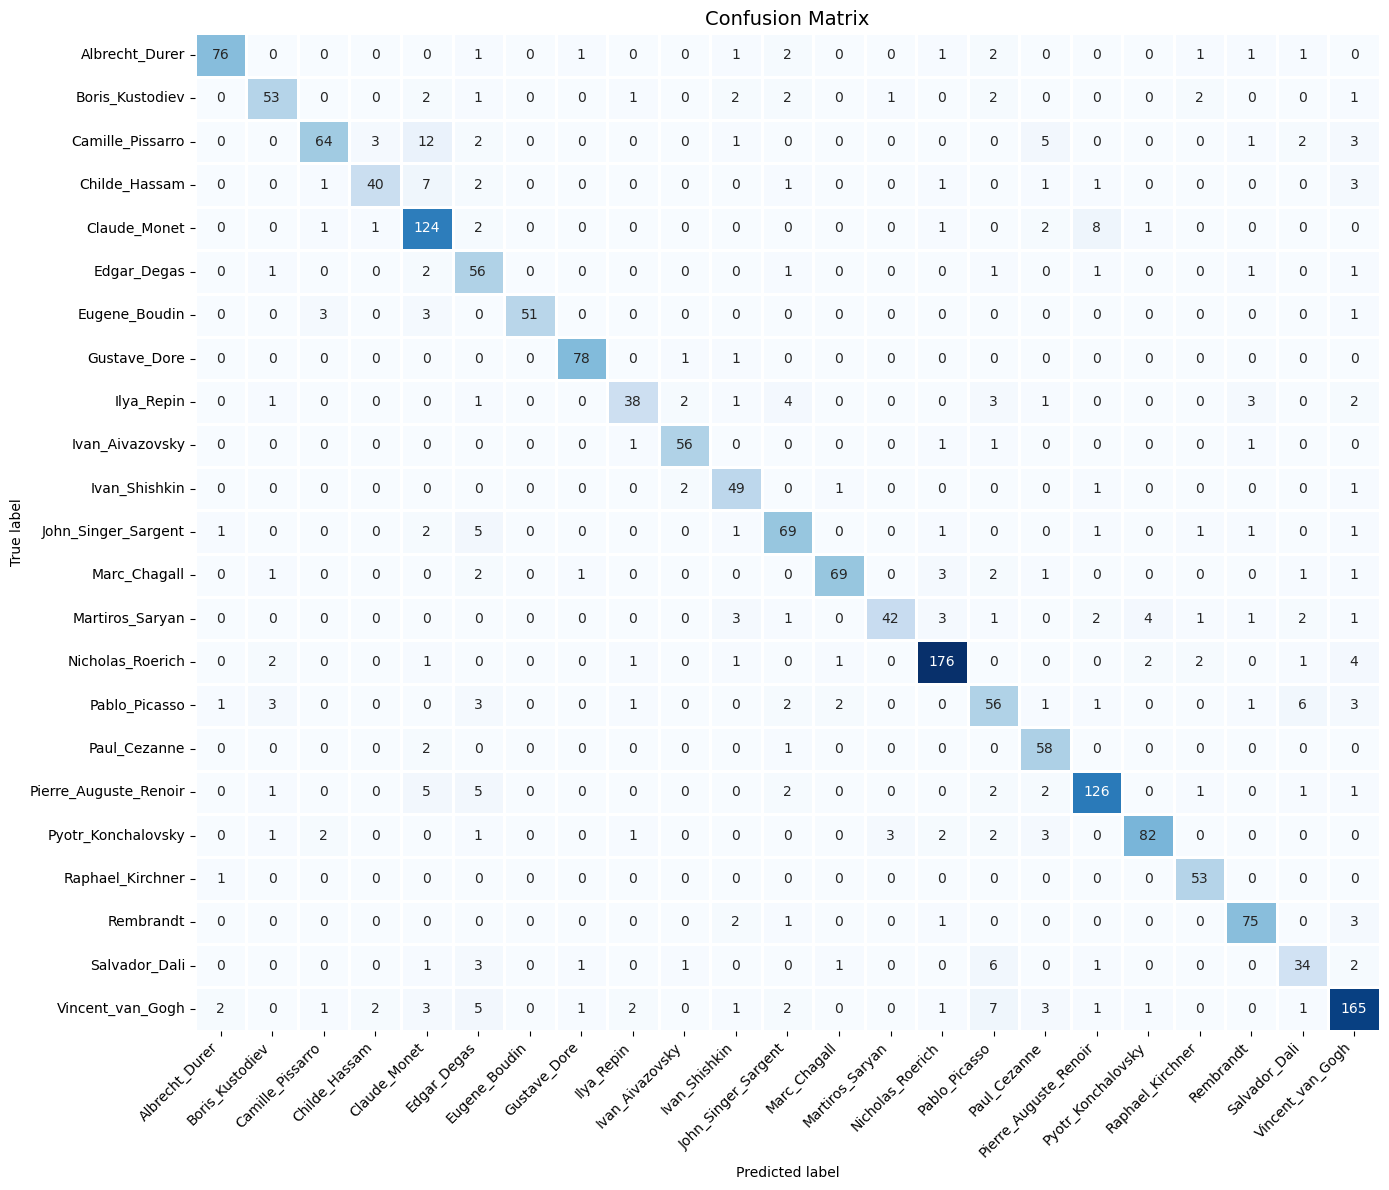


Per-class accuracy:
  Albrecht_Durer                 0.874
  Boris_Kustodiev                0.791
  Camille_Pissarro               0.688
  Childe_Hassam                  0.702
  Claude_Monet                   0.886
  Edgar_Degas                    0.875
  Eugene_Boudin                  0.879
  Gustave_Dore                   0.975
  Ilya_Repin                     0.679
  Ivan_Aivazovsky                0.933
  Ivan_Shishkin                  0.907
  John_Singer_Sargent            0.831
  Marc_Chagall                   0.852
  Martiros_Saryan                0.689
  Nicholas_Roerich               0.921
  Pablo_Picasso                  0.700
  Paul_Cezanne                   0.951
  Pierre_Auguste_Renoir          0.863
  Pyotr_Konchalovsky             0.845
  Raphael_Kirchner               0.981
  Rembrandt                      0.915
  Salvador_Dali                  0.680
  Vincent_van_Gogh               0.833


In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR + '/confusion_matrix_pretrained.png', dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 5. Grad-CAM

Because of Hardware constraints, we ran out of VRAM and couldn't run Grad-CAM for Pretrained Models.

## 6. Misclassified samples

Show the worst predictions — highest confidence but wrong. <br>
Are these images ambiguous? Similar to another class? Possibly mislabelled?

In [ ]:
'''Because of Hardware constraints, we ran out of VRAM and couldn't run this cell.'''

# Collect all misclassified images with their confidence
wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    probs        = model.predict(images, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            wrong_imgs.append(images[i].numpy().astype('uint8'))
            wrong_true.append(true_classes[i])
            wrong_pred.append(pred_classes[i])
            wrong_conf.append(probs[i][pred_classes[i]])   # confidence of wrong prediction

# Sort by highest confidence wrong prediction (worst mistakes)
sorted_idx  = np.argsort(wrong_conf)[::-1]
n_show      = min(10, len(sorted_idx))

print(f'Total misclassified: {len(wrong_imgs)} / {len(y_true)} ({len(wrong_imgs)/len(y_true)*100:.1f}%)')

cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, idx in enumerate(sorted_idx[:n_show]):
    axes[i].imshow(wrong_imgs[idx])
    axes[i].set_title(
        f'True: {class_names[wrong_true[idx]]}\nPred: {class_names[wrong_pred[idx]]}\nConf: {wrong_conf[idx]:.2f}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Most Confident Wrong Predictions', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/misclassified_pretrained.png', dpi=150)
plt.show()

ResourceExhaustedError: Graph execution error:

Detected at node data/_2 defined at (most recent call last):
<stack traces unavailable>
SameWorkerRecvDone unable to allocate output tensor. Key: /job:localhost/replica:0/task:0/device:CPU:0;26cd2d6fd2307f9c;/job:localhost/replica:0/task:0/device:GPU:0;edge_2_data;0:0
	 [[{{node data/_2}}]]
Hint: If you want to see a list of allocated tensors when OOM happens, add report_tensor_allocations_upon_oom to RunOptions for current allocation info. This isn't available when running in Eager mode.
 [Op:__inference_one_step_on_data_distributed_8115]

In [ ]:
print(f"{'Class Name':<30} | {'Total Errors'}")
print("-" * 45)

for i, name in enumerate(class_names):
    # Total images in this class minus the ones on the diagonal (correct)
    total_in_class = cm[i].sum()
    correct_preds = cm[i, i]
    errors = total_in_class - correct_preds
    
    print(f"{name:<30} | {int(errors)}")

Class Name                     | Total Errors
---------------------------------------------
Albrecht_Durer                 | 11
Boris_Kustodiev                | 14
Camille_Pissarro               | 29
Childe_Hassam                  | 17
Claude_Monet                   | 16
Edgar_Degas                    | 8
Eugene_Boudin                  | 7
Gustave_Dore                   | 2
Ilya_Repin                     | 18
Ivan_Aivazovsky                | 4
Ivan_Shishkin                  | 5
John_Singer_Sargent            | 14
Marc_Chagall                   | 12
Martiros_Saryan                | 19
Nicholas_Roerich               | 15
Pablo_Picasso                  | 24
Paul_Cezanne                   | 3
Pierre_Auguste_Renoir          | 20
Pyotr_Konchalovsky             | 15
Raphael_Kirchner               | 1
Rembrandt                      | 7
Salvador_Dali                  | 16
Vincent_van_Gogh               | 33


/tmp/ipykernel_33687/1479890691.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r')


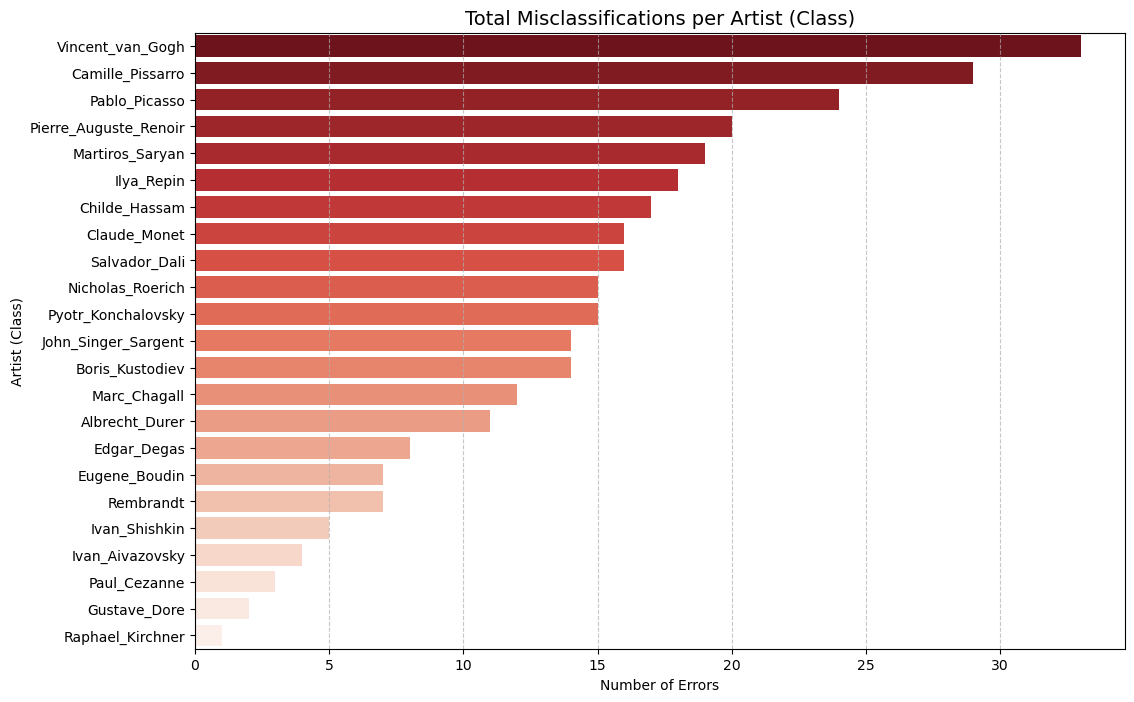

In [ ]:
# Calculate error counts
error_counts = []
for i in range(len(class_names)):
    error_counts.append(cm[i].sum() - cm[i, i]) #cm is the confusion matrix

# Sort by error count
error_val_df = pd.DataFrame({'Artist': class_names, 'Errors': error_counts})
error_val_df = error_val_df.sort_values('Errors', ascending=False)

# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r') 

plt.title('Total Misclassifications per Artist (Class)', fontsize=14)
plt.xlabel('Number of Errors')
plt.ylabel('Artist (Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your project folder
plt.savefig(FIGURES_DIR + '/errors_by_class_pretrained.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_33687/1223538184.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')


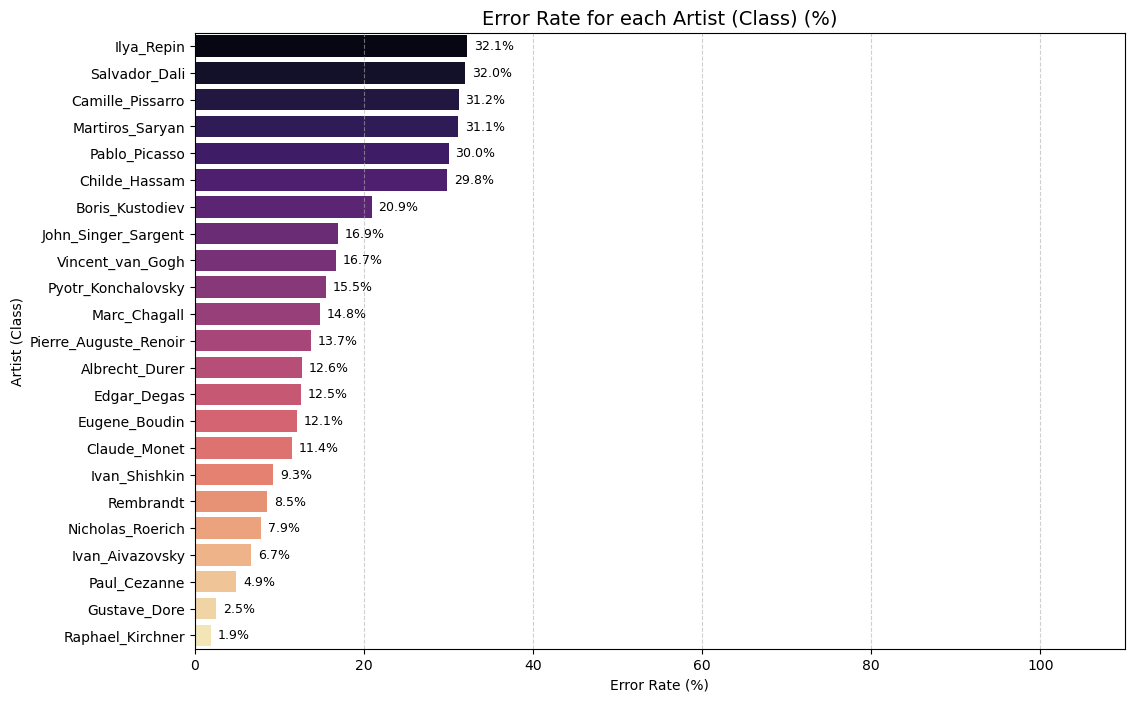

In [ ]:
# percentage of errors for each class

per_class_error_pct = []

for i in range(len(class_names)):
    total_samples = cm[i].sum()
    if total_samples > 0:
        # (Total images - correct predictions / total images) * 100
        error_pct = (1 - (cm[i,i]) / total_samples) * 100
        per_class_error_pct.append(error_pct)
    else:
        per_class_error_pct.append(0)

# Save as DataFrame to ease the visualization

error_df = pd.DataFrame({
    'Artists (Class)': class_names,
    'Error %': per_class_error_pct
}).sort_values('Error %', ascending=False) # Order by the classes with the bigger % of error

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')

# To appear the % on the bars. 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9)

plt.title('Error Rate for each Artist (Class) (%)', fontsize=14)
plt.xlabel('Error Rate (%)')
plt.ylabel('Artist (Class)')
plt.xlim(0, 110) # text
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(FIGURES_DIR + '/error_percentage_by_class_pretrained.png', dpi=150, bbox_inches='tight')
plt.show()